# **BANGLORE TRAFFIC ANALYSIS**

**Importing Libraries:**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the Banglore traffic raw Data set:**

In [3]:
df=pd.read_csv(r"C:\Users\anjan\OneDrive\Desktop\Final Project\Banglore_traffic_Dataset_raw.csv")
df

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8931,2024-08-09,Electronic City,Hosur Road,11387,23.440276,1.262384,35.871483,57.354487,1,72.774,21.523289,83.530352,97.898279,211,Fog,No
8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.500000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No
8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.500000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No
8934,2024-08-09,Jayanagar,South End Circle,20540,52.254798,1.020520,72.639152,97.845527,2,91.080,44.416043,89.586947,79.197198,94,Clear,No


**Initial Inspections:**

In [4]:
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [5]:
df.tail()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
8931,2024-08-09,Electronic City,Hosur Road,11387,23.440276,1.262384,35.871483,57.354487,1,72.774,21.523289,83.530352,97.898279,211,Fog,No
8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.500000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No
8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.500000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No
8934,2024-08-09,Jayanagar,South End Circle,20540,52.254798,1.020520,72.639152,97.845527,2,91.080,44.416043,89.586947,79.197198,94,Clear,No
8935,2024-08-09,Yeshwanthpur,Yeshwanthpur Circle,14705,31.128967,1.048720,43.409821,77.734621,1,79.410,26.616725,80.778753,60.602672,201,Rain,No


In [6]:
df.shape

(8936, 16)

In [7]:
df.dtypes

Date                                   object
Area Name                              object
Road/Intersection Name                 object
Traffic Volume                          int64
Average Speed                         float64
Travel Time Index                     float64
Congestion Level                      float64
Road Capacity Utilization             float64
Incident Reports                        int64
Environmental Impact                  float64
Public Transport Usage                float64
Traffic Signal Compliance             float64
Parking Usage                         float64
Pedestrian and Cyclist Count            int64
Weather Conditions                     object
Roadwork and Construction Activity     object
dtype: object

In [8]:
df.describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

In [10]:
df.columns

Index(['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume',
       'Average Speed', 'Travel Time Index', 'Congestion Level',
       'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
       'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count', 'Weather Conditions',
       'Roadwork and Construction Activity'],
      dtype='object')

In [11]:
df.notnull()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8931,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8932,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8933,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8934,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [12]:
df.isnull()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8931,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8932,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8933,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8934,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
print(df[['Area Name', 'Road/Intersection Name']].nunique())

Area Name                  8
Road/Intersection Name    16
dtype: int64


**To ensure the reliability of our spatial analysis:** Checking if the same area appears with different spellings

In [16]:
print("Unique Areas:")
print(df['Area Name'].unique())

print("\nUnique Intersections:")
print(df['Road/Intersection Name'].unique())

Unique Areas:
['Indiranagar' 'Whitefield' 'Koramangala' 'M.G. Road' 'Jayanagar' 'Hebbal'
 'Yeshwanthpur' 'Electronic City']

Unique Intersections:
['100 Feet Road' 'CMH Road' 'Marathahalli Bridge' 'Sony World Junction'
 'Sarjapur Road' 'Trinity Circle' 'Anil Kumble Circle'
 'Jayanagar 4th Block' 'South End Circle' 'Hebbal Flyover' 'Ballari Road'
 'Yeshwanthpur Circle' 'Tumkur Road' 'ITPL Main Road'
 'Silk Board Junction' 'Hosur Road']


**Outliers Detection and Outliers Removal:**

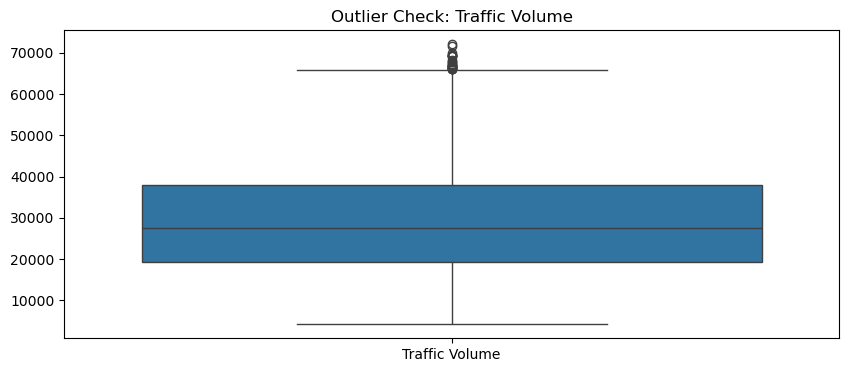

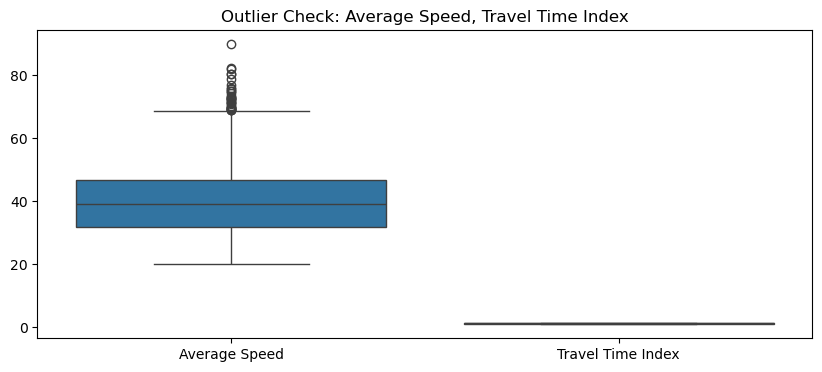

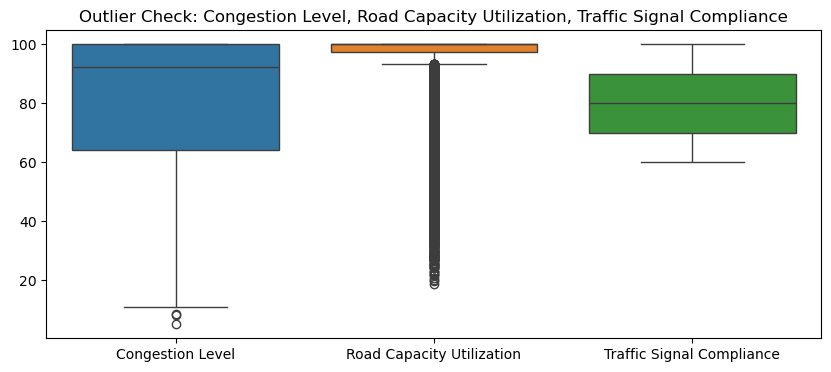

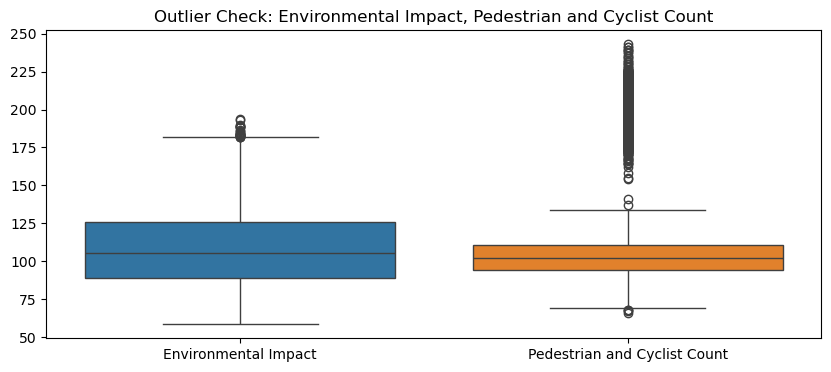

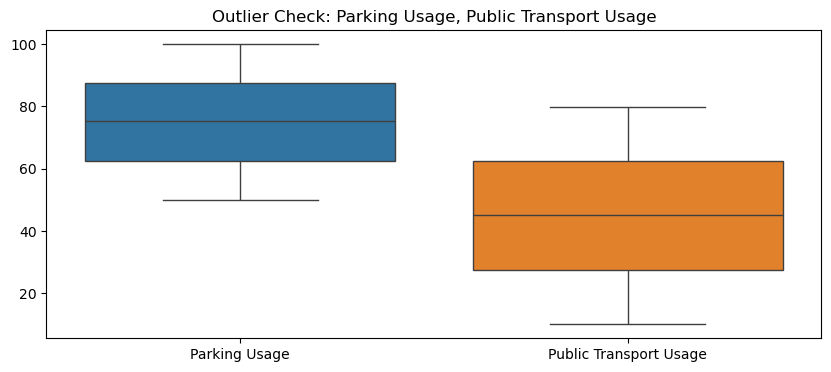

In [17]:

groups = [
    ['Traffic Volume'],
    ['Average Speed', 'Travel Time Index'],
    ['Congestion Level', 'Road Capacity Utilization', 'Traffic Signal Compliance'],
    ['Environmental Impact', 'Pedestrian and Cyclist Count'],
    ['Parking Usage', 'Public Transport Usage']]
for group in groups:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df[group])
    plt.title(f"Outlier Check: {', '.join(group)}")
    plt.show()

**Removal of Outliers:** 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level','Road Capacity Utilization','Environmental Impact','Pedestrian and Cyclist Count'- These 6 columns have outliers but,
**The decision to keep or remove data points depends on whether they represent a Real-World Event or a Technical Error**
So,
Keeping 'Traffic Volume','Congestion Level','Environmental Impact','Pedestrian and Cyclist Count' columns because these are the most important parts of the "Story." They represent the city's breaking points.


Dataset reduced from 8936 to 6839 rows.


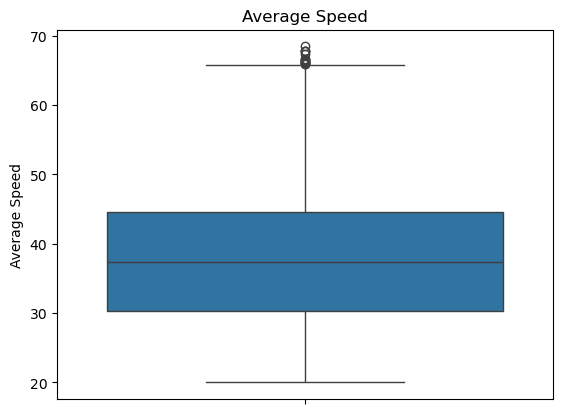

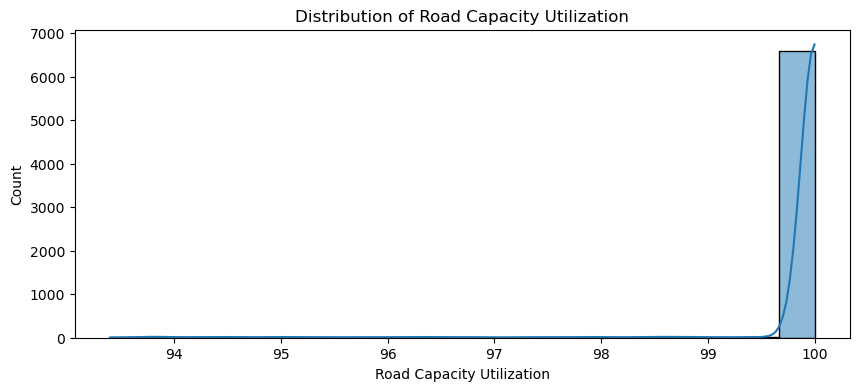

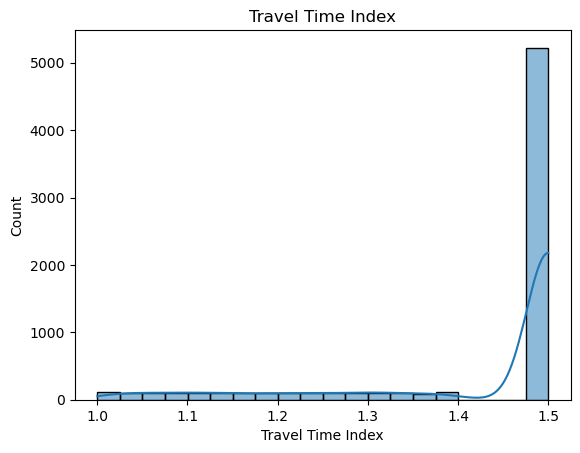

In [18]:
cols_to_clean = ['Average Speed', 'Travel Time Index', 'Road Capacity Utilization']

Q1 = df[cols_to_clean].quantile(0.25)
Q2 = df[cols_to_clean].quantile(0.50)
Q3 = df[cols_to_clean].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

is_clean = ((df[cols_to_clean] >= lower_limit) & (df[cols_to_clean] <= upper_limit)).all(axis=1)

df_filtered = df[is_clean].copy()

print(f"Dataset reduced from {len(df)} to {len(df_filtered)} rows.")

sns.boxplot(data=df_filtered['Average Speed'])
plt.title('Average Speed')
plt.show()
plt.figure(figsize=(10, 4))

sns.histplot(df_filtered['Road Capacity Utilization'], bins=20, kde=True)
plt.title('Distribution of Road Capacity Utilization')
plt.show()

sns.histplot(df_filtered['Travel Time Index'], bins=20, kde=True,)
plt.title('Travel Time Index')
plt.show()

**I performed a single-pass IQR filtering to remove extreme sensor errors (values above 90 km/h). The remaining 'minor' outliers were intentionally preserved as they represent legitimate high-speed variations in urban mobility that are essential for a realistic analysis.**

Box plots of Time Travel Index & Road Capacity Utilization look "broken" or unusual because of a phenomenon called **Box Plot Collapse** ie, this data has extremely low variance or when the majority of this data points are exactly the same value.

Histogram will show a massive "spike" at 100 for Capacity and a spike at 1.0 for Travel Time. This is much easier for an audience to understand than a "collapsed" box.

In [19]:
df_filtered.reset_index()

,index,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.50000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.50000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.50000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
3,4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.50000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No
4,5,2022-01-01,M.G. Road,Trinity Circle,47848,34.241963,1.50000,100.000000,100.000000,3,145.696,39.927871,61.016765,55.394571,94,Overcast,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6834,8929,2024-08-09,Koramangala,Sony World Junction,27673,20.000000,1.50000,93.969031,100.000000,0,105.346,57.726520,88.795917,83.965889,96,Overcast,Yes
6835,8930,2024-08-09,Koramangala,Sarjapur Road,58992,43.138451,1.50000,100.000000,100.000000,2,167.984,68.810804,69.859257,64.179922,101,Clear,No
6836,8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.50000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No
6837,8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.50000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No


In [20]:
print(df.shape)
print(df_filtered.shape)
df

(8936, 16)
(6839, 16)


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8931,2024-08-09,Electronic City,Hosur Road,11387,23.440276,1.262384,35.871483,57.354487,1,72.774,21.523289,83.530352,97.898279,211,Fog,No
8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.500000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No
8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.500000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No
8934,2024-08-09,Jayanagar,South End Circle,20540,52.254798,1.020520,72.639152,97.845527,2,91.080,44.416043,89.586947,79.197198,94,Clear,No


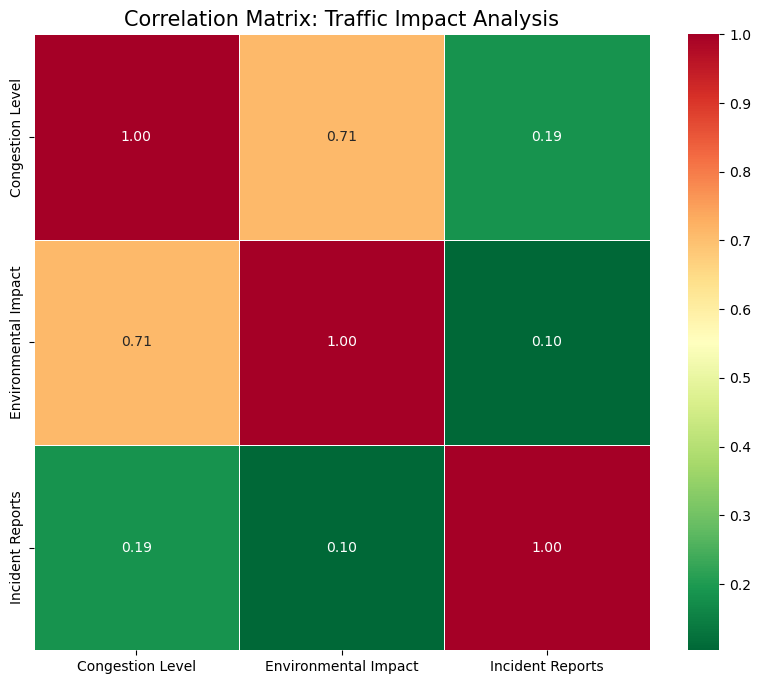

In [21]:
corr_cols = ['Congestion Level', 'Environmental Impact', 'Incident Reports']
matrix = df_filtered[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(data=matrix, annot=True, cmap='RdYlGn_r',fmt='.2f', linewidths=0.5,square=True)

plt.title('Correlation Matrix: Traffic Impact Analysis', fontsize=15)
plt.show()

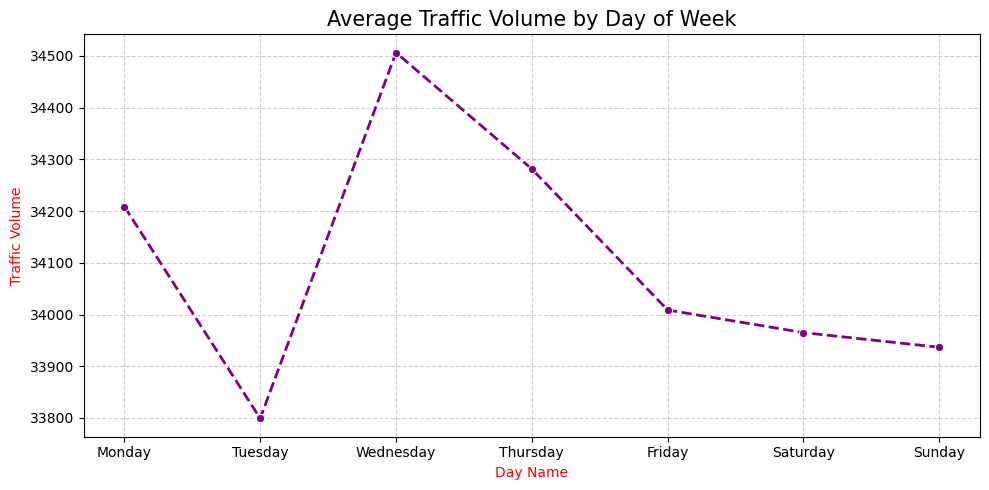

In [22]:
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])

# 1. Extract the Day of the Week (0=Monday, 6=Sunday)
df_filtered['Day_of_Week'] = df_filtered['Date'].dt.dayofweek
df_filtered['Day_Name'] = df_filtered['Date'].dt.day_name()

daily_trend = df_filtered.groupby(['Day_of_Week', 'Day_Name'])['Traffic Volume'].mean().reset_index()
daily_trend = daily_trend.sort_values('Day_of_Week')

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_trend, x='Day_Name', y='Traffic Volume', marker='o', linewidth=2, linestyle="--",color="purple",sort=False) 

plt.title('Average Traffic Volume by Day of Week', fontsize=15)
plt.xlabel('Day Name', color='red')
plt.ylabel('Traffic Volume', color='red')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


C:\Users\anjan\AppData\Local\Temp\ipykernel_17852\944289334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_chokepoints,


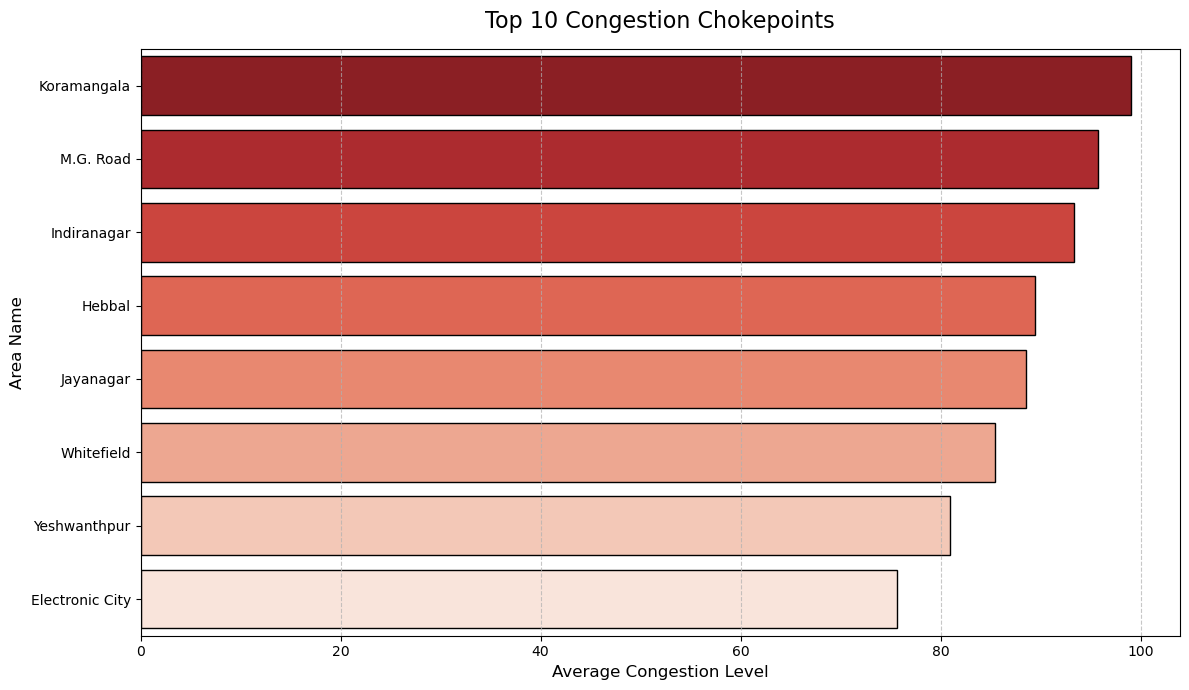

In [23]:
top_10_chokepoints = df_filtered.groupby('Area Name')['Congestion Level'].mean().reset_index()
top_10_chokepoints = top_10_chokepoints.sort_values(by='Congestion Level', ascending=False).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(data=top_10_chokepoints, 
            x='Congestion Level', 
            y='Area Name', 
            palette='Reds_r', 
            edgecolor='black')

plt.title('Top 10 Congestion Chokepoints', fontsize=16, pad=15)
plt.xlabel('Average Congestion Level', fontsize=12)
plt.ylabel('Area Name', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\anjan\AppData\Local\Temp\ipykernel_17852\2476580063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather Conditions', y='Average Speed', data=df, palette='muted')


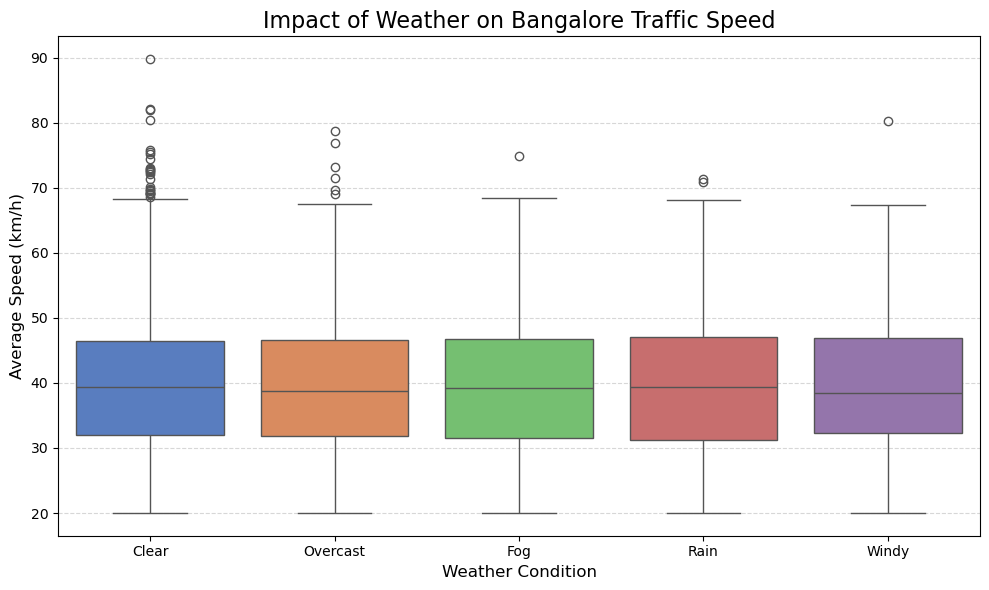

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Weather Conditions', y='Average Speed', data=df, palette='muted')

plt.title('Impact of Weather on Bangalore Traffic Speed', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Speed (km/h)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The interquartile range (middle 50% of data) is nearly identical across Clear, Fog, Overcast, Rain, and Windy days.

C:\Users\anjan\AppData\Local\Temp\ipykernel_17852\3184606466.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_chokepoints, x='Congestion Level', y='Area Name', palette='Reds_r', edgecolor='black')
C:\Users\anjan\AppData\Local\Temp\ipykernel_17852\3184606466.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather Conditions', y='Average Speed', data=df, palette='muted')


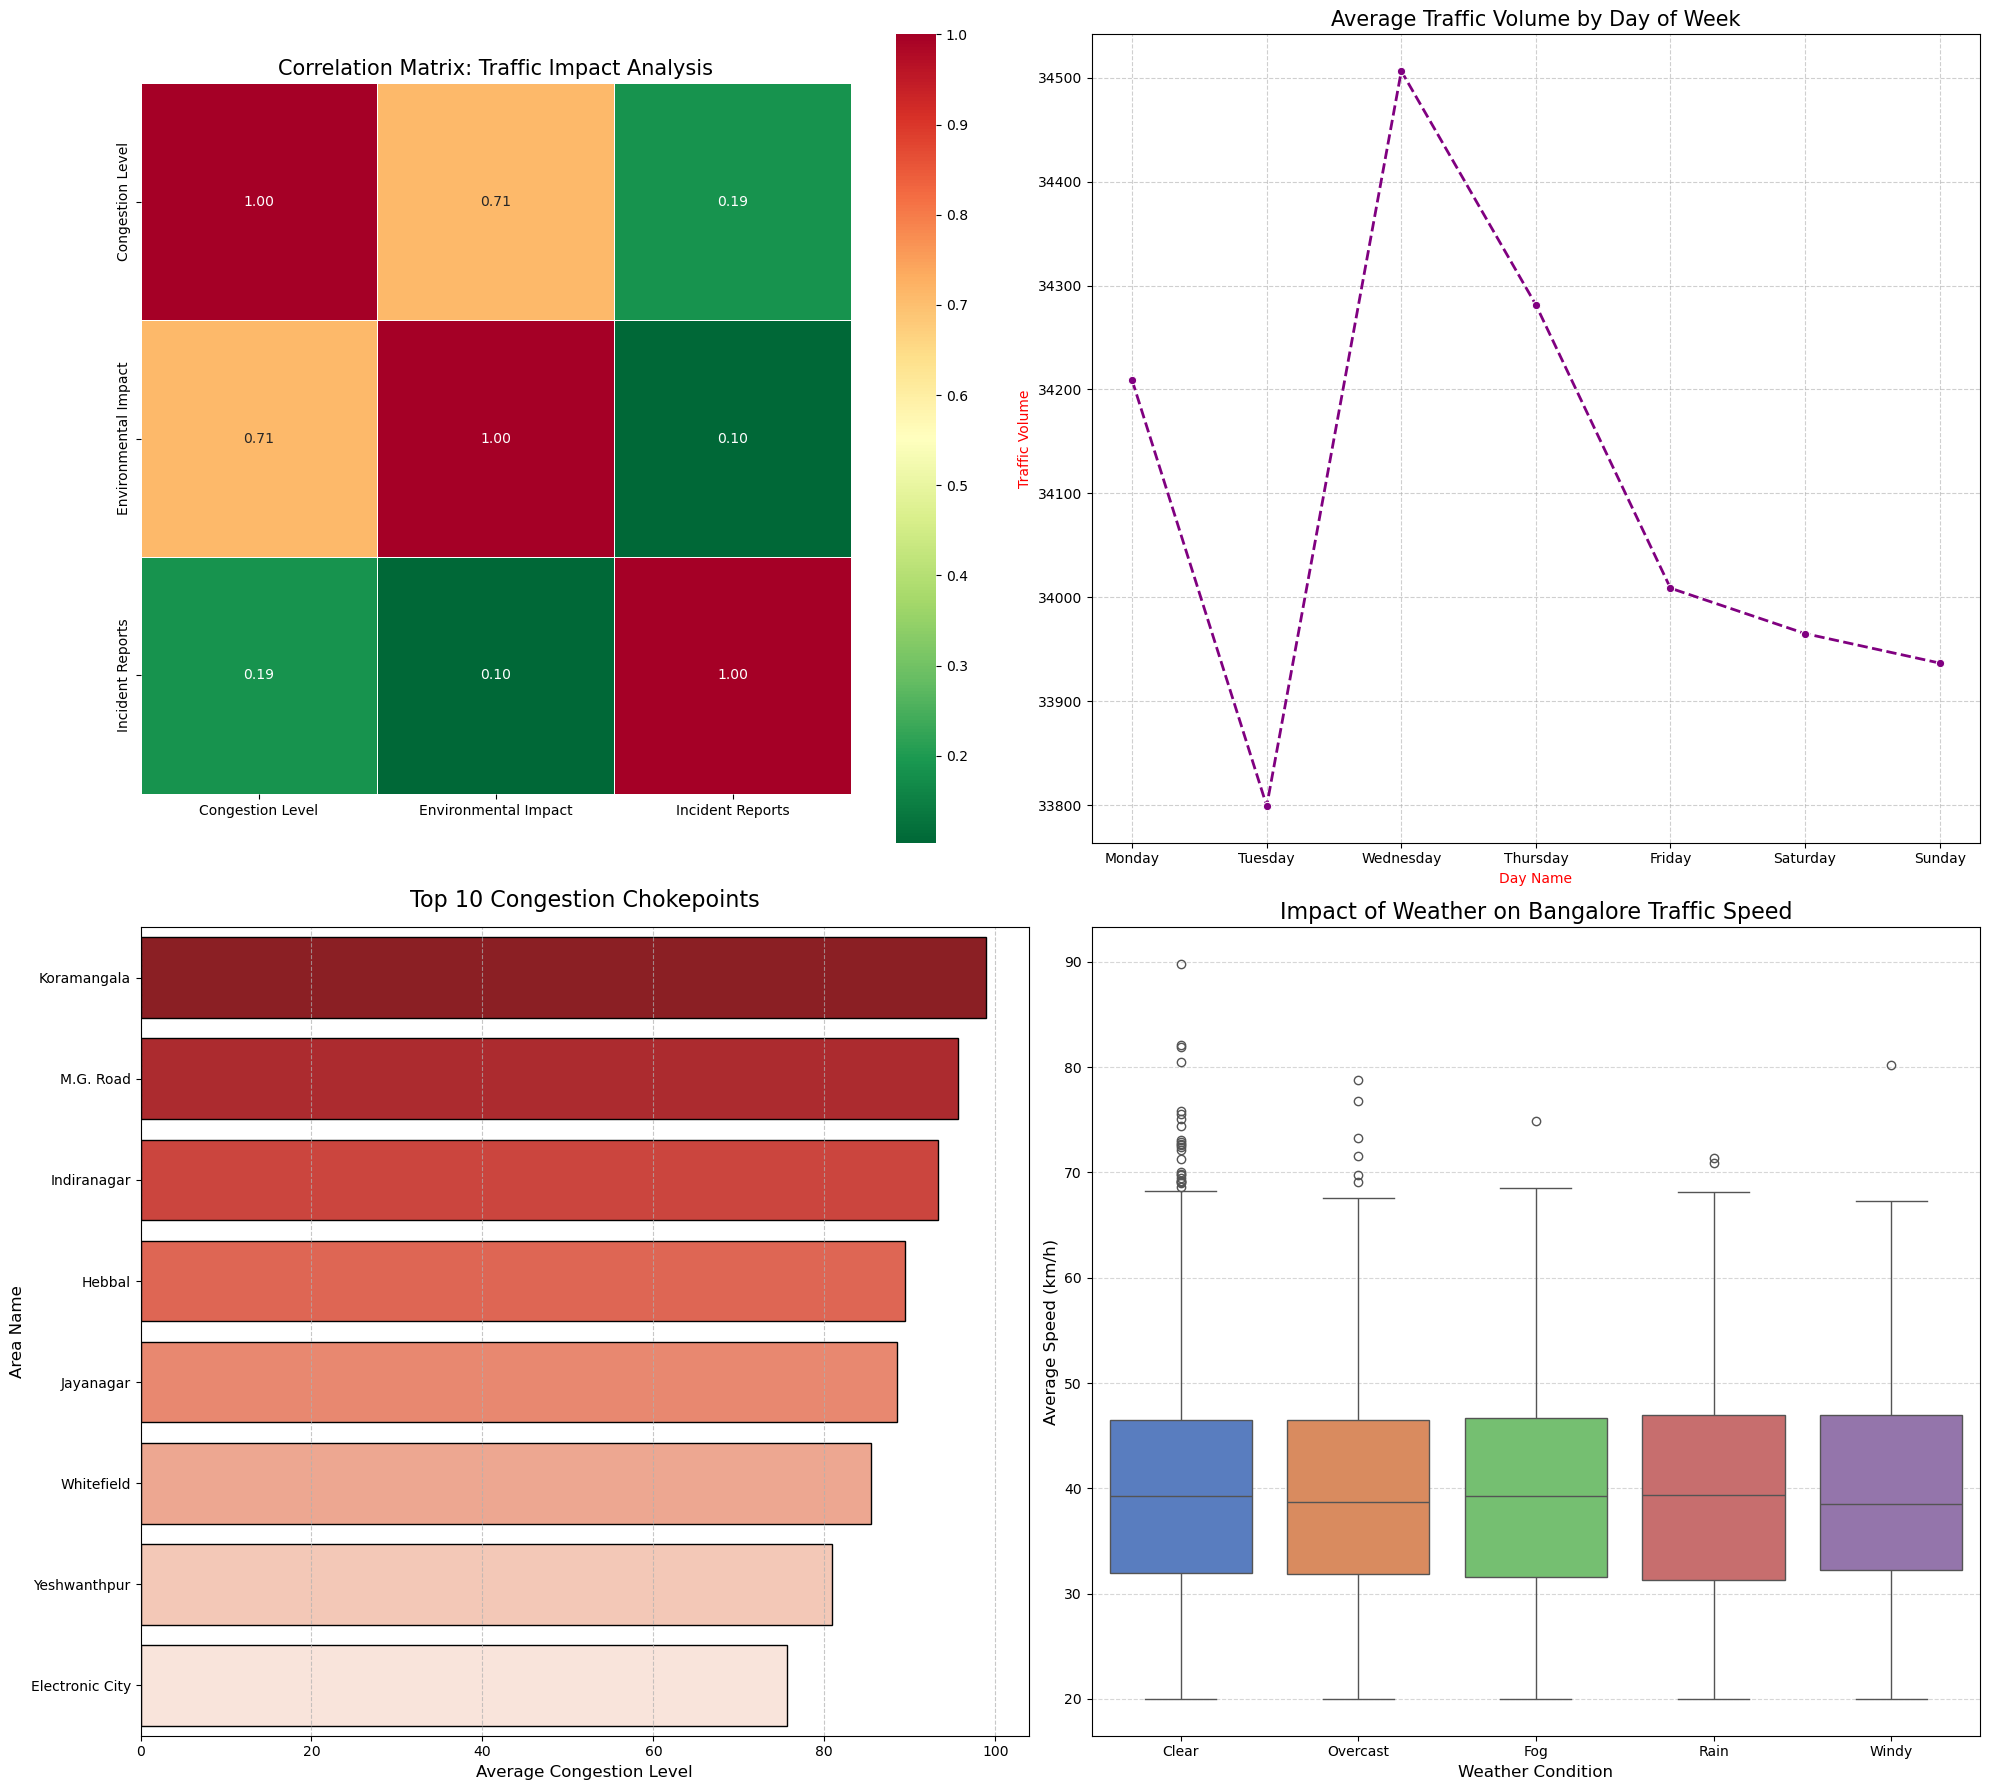

In [25]:
plt.figure(figsize=(20,18))

plt.subplot(2,2,1)
corr_cols = ['Congestion Level', 'Environmental Impact', 'Incident Reports']
matrix = df_filtered[corr_cols].corr()
sns.heatmap(data=matrix, annot=True, cmap='RdYlGn_r',fmt='.2f', linewidths=0.5,square=True)
plt.title('Correlation Matrix: Traffic Impact Analysis', fontsize=15)


plt.subplot(2,2,2)
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])
df_filtered['Day_of_Week'] = df_filtered['Date'].dt.dayofweek
df_filtered['Day_Name'] = df_filtered['Date'].dt.day_name()
daily_trend = df_filtered.groupby(['Day_of_Week', 'Day_Name'])['Traffic Volume'].mean().reset_index()
daily_trend = daily_trend.sort_values('Day_of_Week')
sns.lineplot(data=daily_trend, x='Day_Name', y='Traffic Volume', marker='o', linewidth=2, linestyle="--",color="purple",sort=False) 
plt.title('Average Traffic Volume by Day of Week', fontsize=15)
plt.xlabel('Day Name', color='red')
plt.ylabel('Traffic Volume', color='red')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2,2,3)
top_10_chokepoints = df_filtered.groupby('Area Name')['Congestion Level'].mean().reset_index()
top_10_chokepoints = top_10_chokepoints.sort_values(by='Congestion Level', ascending=False).head(10)
sns.barplot(data=top_10_chokepoints, x='Congestion Level', y='Area Name', palette='Reds_r', edgecolor='black')
plt.title('Top 10 Congestion Chokepoints', fontsize=16, pad=15)
plt.xlabel('Average Congestion Level', fontsize=12)
plt.ylabel('Area Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(2,2,4)
sns.boxplot(x='Weather Conditions', y='Average Speed', data=df, palette='muted')
plt.title('Impact of Weather on Bangalore Traffic Speed', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Speed (km/h)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
# Export the cleaned dataframe to a CSV file
save_path = r'C:\Users\anjan\OneDrive\Desktop\Final Project\bangalore_traffic_cleaned_final.csv'
df_filtered.to_csv(save_path, index=False)

print("Export Complete! Ready for Power BI.")

Export Complete! Ready for Power BI.
